In [40]:
### Hayden Gallo
### Bucci Lab
### Plotting flux sampling data from hpc simulations
### 7/22/25

import numpy as np
#from dfba import DfbaModel, ExchangeFlux, KineticVariable
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from numba import njit
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import sys
import os
import openpyxl
import gurobipy

import pymc as pm
import pytensor
import pytensor.tensor as pt
from pymc.ode import DifferentialEquation
from pytensor.compile.ops import as_op
import arviz as az

import time
import joblib
import multiprocessing
from scipy.stats import truncnorm
import copy
from pathlib import Path
import subprocess

### script for running glv_dfba inference
from helper_functions import *
import itertools
from collections import Counter

import matplotlib.lines as lines
import json

In [41]:
main_directory = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_flux_sampling_test_1/'

In [42]:
### load in dietary and initial metabolite data for filtering 

### change over init values to correct kbase nomenclature 

metabolomics_data = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/complete_mapping_metabolomics.csv', index_col=0)
## fill NAs w/ zero 
metabolomics_data = metabolomics_data.fillna(0)

    ### load in metabolomics metadata

metabolomics_metadata_raw = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/metabolomics_meta.csv', index_col=0)
# filtered metabolomics metadata for subject 1948 initial sample 
metabolomics_metadata = metabolomics_metadata_raw.copy()
metabolomics_metadata = metabolomics_metadata[(metabolomics_metadata['Mouse'] == float(1948)) & (metabolomics_metadata['Rec_day_adj'] == -3)]
metabolomics_metadata.index.tolist()

metabolomics_data_initial_sub_1948 = metabolomics_data[metabolomics_data['SampleName'] == metabolomics_metadata.index.tolist()[0]]

metabolomics_data_initial_sub_1948.iloc[:,1:].T.index.tolist()

with open('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/BiGG_to_MSID.json') as f:
    bigg_to_modelseed = json.load(f)

cmpd_names = []
for i in metabolomics_data_initial_sub_1948.iloc[:,1:].T.index.tolist():
    cmpd_names.append(bigg_to_modelseed[i])

metabolomics_data_initial_sub_1948 = metabolomics_data_initial_sub_1948.iloc[:,1:].T

metabolomics_data_initial_sub_1948.index = cmpd_names
metabolomics_data_initial_sub_1948.reset_index(inplace=True)
metabolomics_data_initial_sub_1948.columns = ['reaction', 'fluxValue']

metabolomics_data_initial_sub_1948

for i in range(0, len(metabolomics_data_initial_sub_1948)):
    metabolomics_data_initial_sub_1948['reaction'].iloc[i] = 'EX_' + metabolomics_data_initial_sub_1948['reaction'].iloc[i]  + '_b'

metabolomics_data_initial_sub_1948  

/var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/ipykernel_97786/2396387582.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  metabolomics_data_initial_sub_1948['reaction'].iloc[i] = 'EX_' + metabolomics_data_initial_sub_1948['reaction'].

,reaction,fluxValue
0,EX_cpd35610_b,0.191
1,EX_cpd01242_b,0.216
2,EX_cpd01293_b,0.230
3,EX_cpd00035_b,6.221
4,EX_cpd01055_b,0.040
5,EX_cpd00224_b,10.247
6,EX_cpd00132_b,0.000
7,EX_cpd00041_b,0.266
8,EX_cpd00158_b,0.246
9,EX_cpd00526_b,0.186


In [43]:
### Reading in all of the data from the simulation 

abun_to_store =[]
met_to_store =[]

conditions = ['Subject_1507_met']#, 'Subject_1953_met', 'Subject_1999_met']
for j, name in enumerate(conditions):
    subdirectory = main_directory + name
    temp_abun = []
    temp_met =[]
    for i in range(0,500):
        
        temp_dir = subdirectory + '/sim_' + str(i) + '_met_save.npy'
        #print(temp_dir)
        if os.path.exists(temp_dir):
            print(temp_dir)
            #met = subdirectory + '/sim_' + str(i) + '_abun_save.npy'
            #abun = temp_dir + '/model_abun_dict.npy'
            met = np.load(temp_dir, allow_pickle=True)
            #abun = np.load(abun, allow_pickle=True)
            temp_met.append(met)
            #temp_abun.append(abun.item())
    #abun_to_store.append(temp_abun)
    met_to_store.append(temp_met)   

/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_flux_sampling_test_1/Subject_1507_met/sim_1_met_save.npy
/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_flux_sampling_test_1/Subject_1507_met/sim_8_met_save.npy
/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_flux_sampling_test_1/Subject_1507_met/sim_9_met_save.npy
/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_flux_sampling_test_1/Subject_1507_met/sim_10_met_save.npy
/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Buc

In [44]:
### set num sim points here

num_sim_pts = 415


# converting our dictionaries to dataframes 

df_met_storage = []
df_stacked_storage=[]
index = []
for j in range(0, len(met_to_store)):
    temp_df_met_storage =[]
    temp_df_stacked_storage =[]
    temp_index = []
    for i in range(0, len(met_to_store[j])):
        test = pd.DataFrame(met_to_store[j][i].tolist())
        test = np.transpose(test)
        test = test.fillna(0)
        diff_df = pd.DataFrame(test.iloc[:,0] - test.iloc[:,num_sim_pts])
        diff_df.columns = ['diff']
        ### this line removes metabolites that don't change overtime at all or at least there is no difference between t=0 and t=f
        # maybe this is unneccessary here 
        test_filt = test[test.index.isin(diff_df[diff_df['diff'] !=0].index)]
        temp_df_stacked_storage.append(test_filt)
        temp_index.append(test_filt.index.tolist())
        test_unstack = test_filt.unstack()
        test_unstack = pd.DataFrame(test_unstack).reset_index()
        test_unstack.columns = ['time', 'reaction', 'fluxValue']
        temp_df_met_storage.append(test_unstack)

    df_met_storage.append(temp_df_met_storage)
    df_stacked_storage.append(temp_df_stacked_storage)
    index.append(temp_index)    

In [47]:
list_df_concat = []

for i in range(0, len(index)):

    index_full = list(itertools.chain.from_iterable(index[i]))
    index_unique = np.unique(index_full).tolist()
    index_full_unique = index_unique * len(df_stacked_storage[i])
    df_concat = pd.concat(df_stacked_storage[i], join='outer')
    df_concat_index = df_concat.index.tolist()
    final = Counter(index_full_unique) - Counter(df_concat_index)
    missing_elems = list(final.elements())
    df_to_append = np.zeros([len(missing_elems), (df_concat.shape[1])])
    df_to_append = pd.DataFrame(df_to_append)
    df_to_append.index = missing_elems
    df_concat = pd.concat([df_concat, df_to_append], join='outer')
    list_df_concat.append(df_concat)

In [57]:
melted_df = list_df_concat[0].melt(ignore_index=False)
melted_df.columns = ['time', 'fluxValue']
melted_df = melted_df.reset_index()
melted_df.columns = ['reaction','time', 'fluxValue']
melted_df = melted_df[melted_df['reaction'].isin(metabolomics_data_initial_sub_1948['reaction'].to_list())]
melted_df

,reaction,time,fluxValue
0,EX_cpd35610_b,0,0.147
1,EX_cpd01242_b,0,0.381
2,EX_cpd01293_b,0,0.637
3,EX_cpd00035_b,0,15.682
4,EX_cpd01055_b,0,0.035
...,...,...,...
10718696,EX_cpd00158_b,415,0.000
10718697,EX_cpd00158_b,415,0.000
10718698,EX_cpd00158_b,415,0.000
10718699,EX_cpd00158_b,415,0.000


In [58]:
#melted_df_sub = melted_df.iloc[:1000000,:]
#melted_df_sub

,reaction,time,fluxValue
0,EX_cpd35610_b,0,0.147000
1,EX_cpd01242_b,0,0.381000
2,EX_cpd01293_b,0,0.637000
3,EX_cpd00035_b,0,15.682000
4,EX_cpd01055_b,0,0.035000
...,...,...,...
3030588,EX_cpd02733_b,117,1.029389
3030589,EX_cpd01741_b,117,0.354878
3030590,EX_cpd00082_b,117,2.570261
3030591,EX_cpd00751_b,117,0.078406


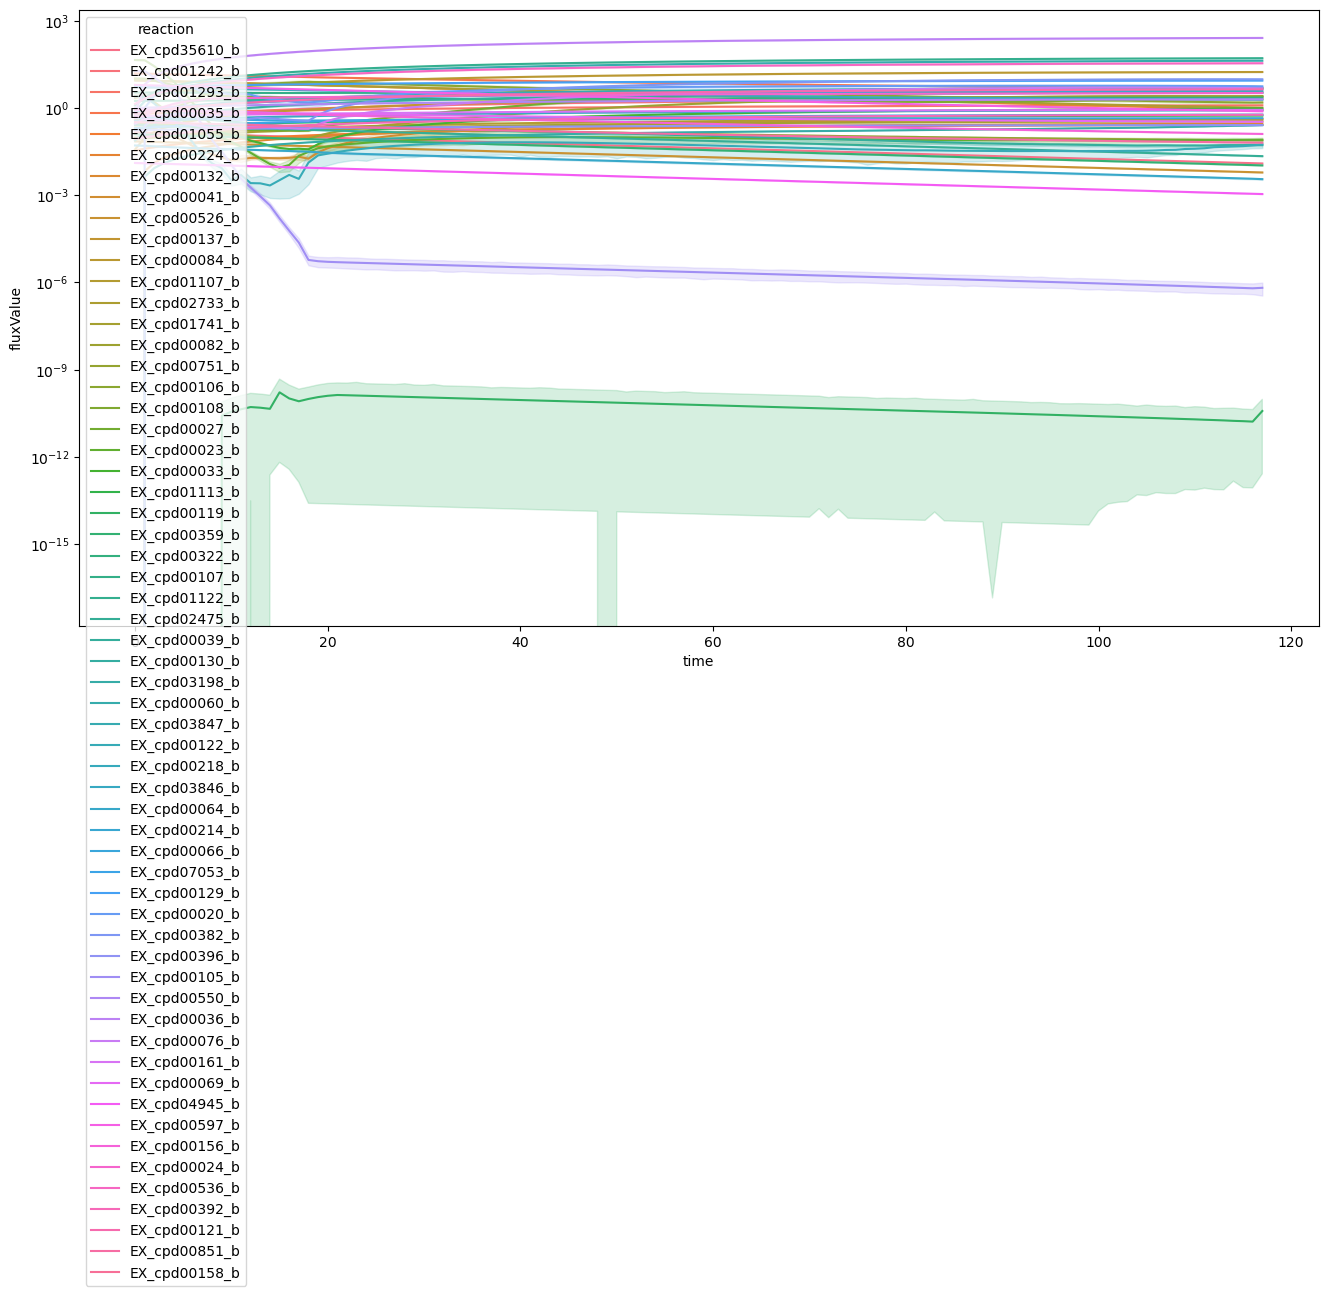

In [60]:
# Your existing lineplot
fig, axs = plt.subplots(figsize= (16,8))
sns.lineplot(data=melted_df, x='time', y='fluxValue', hue='reaction')
plt.yscale('log')

IndexError: index 60 is out of bounds for axis 0 with size 60

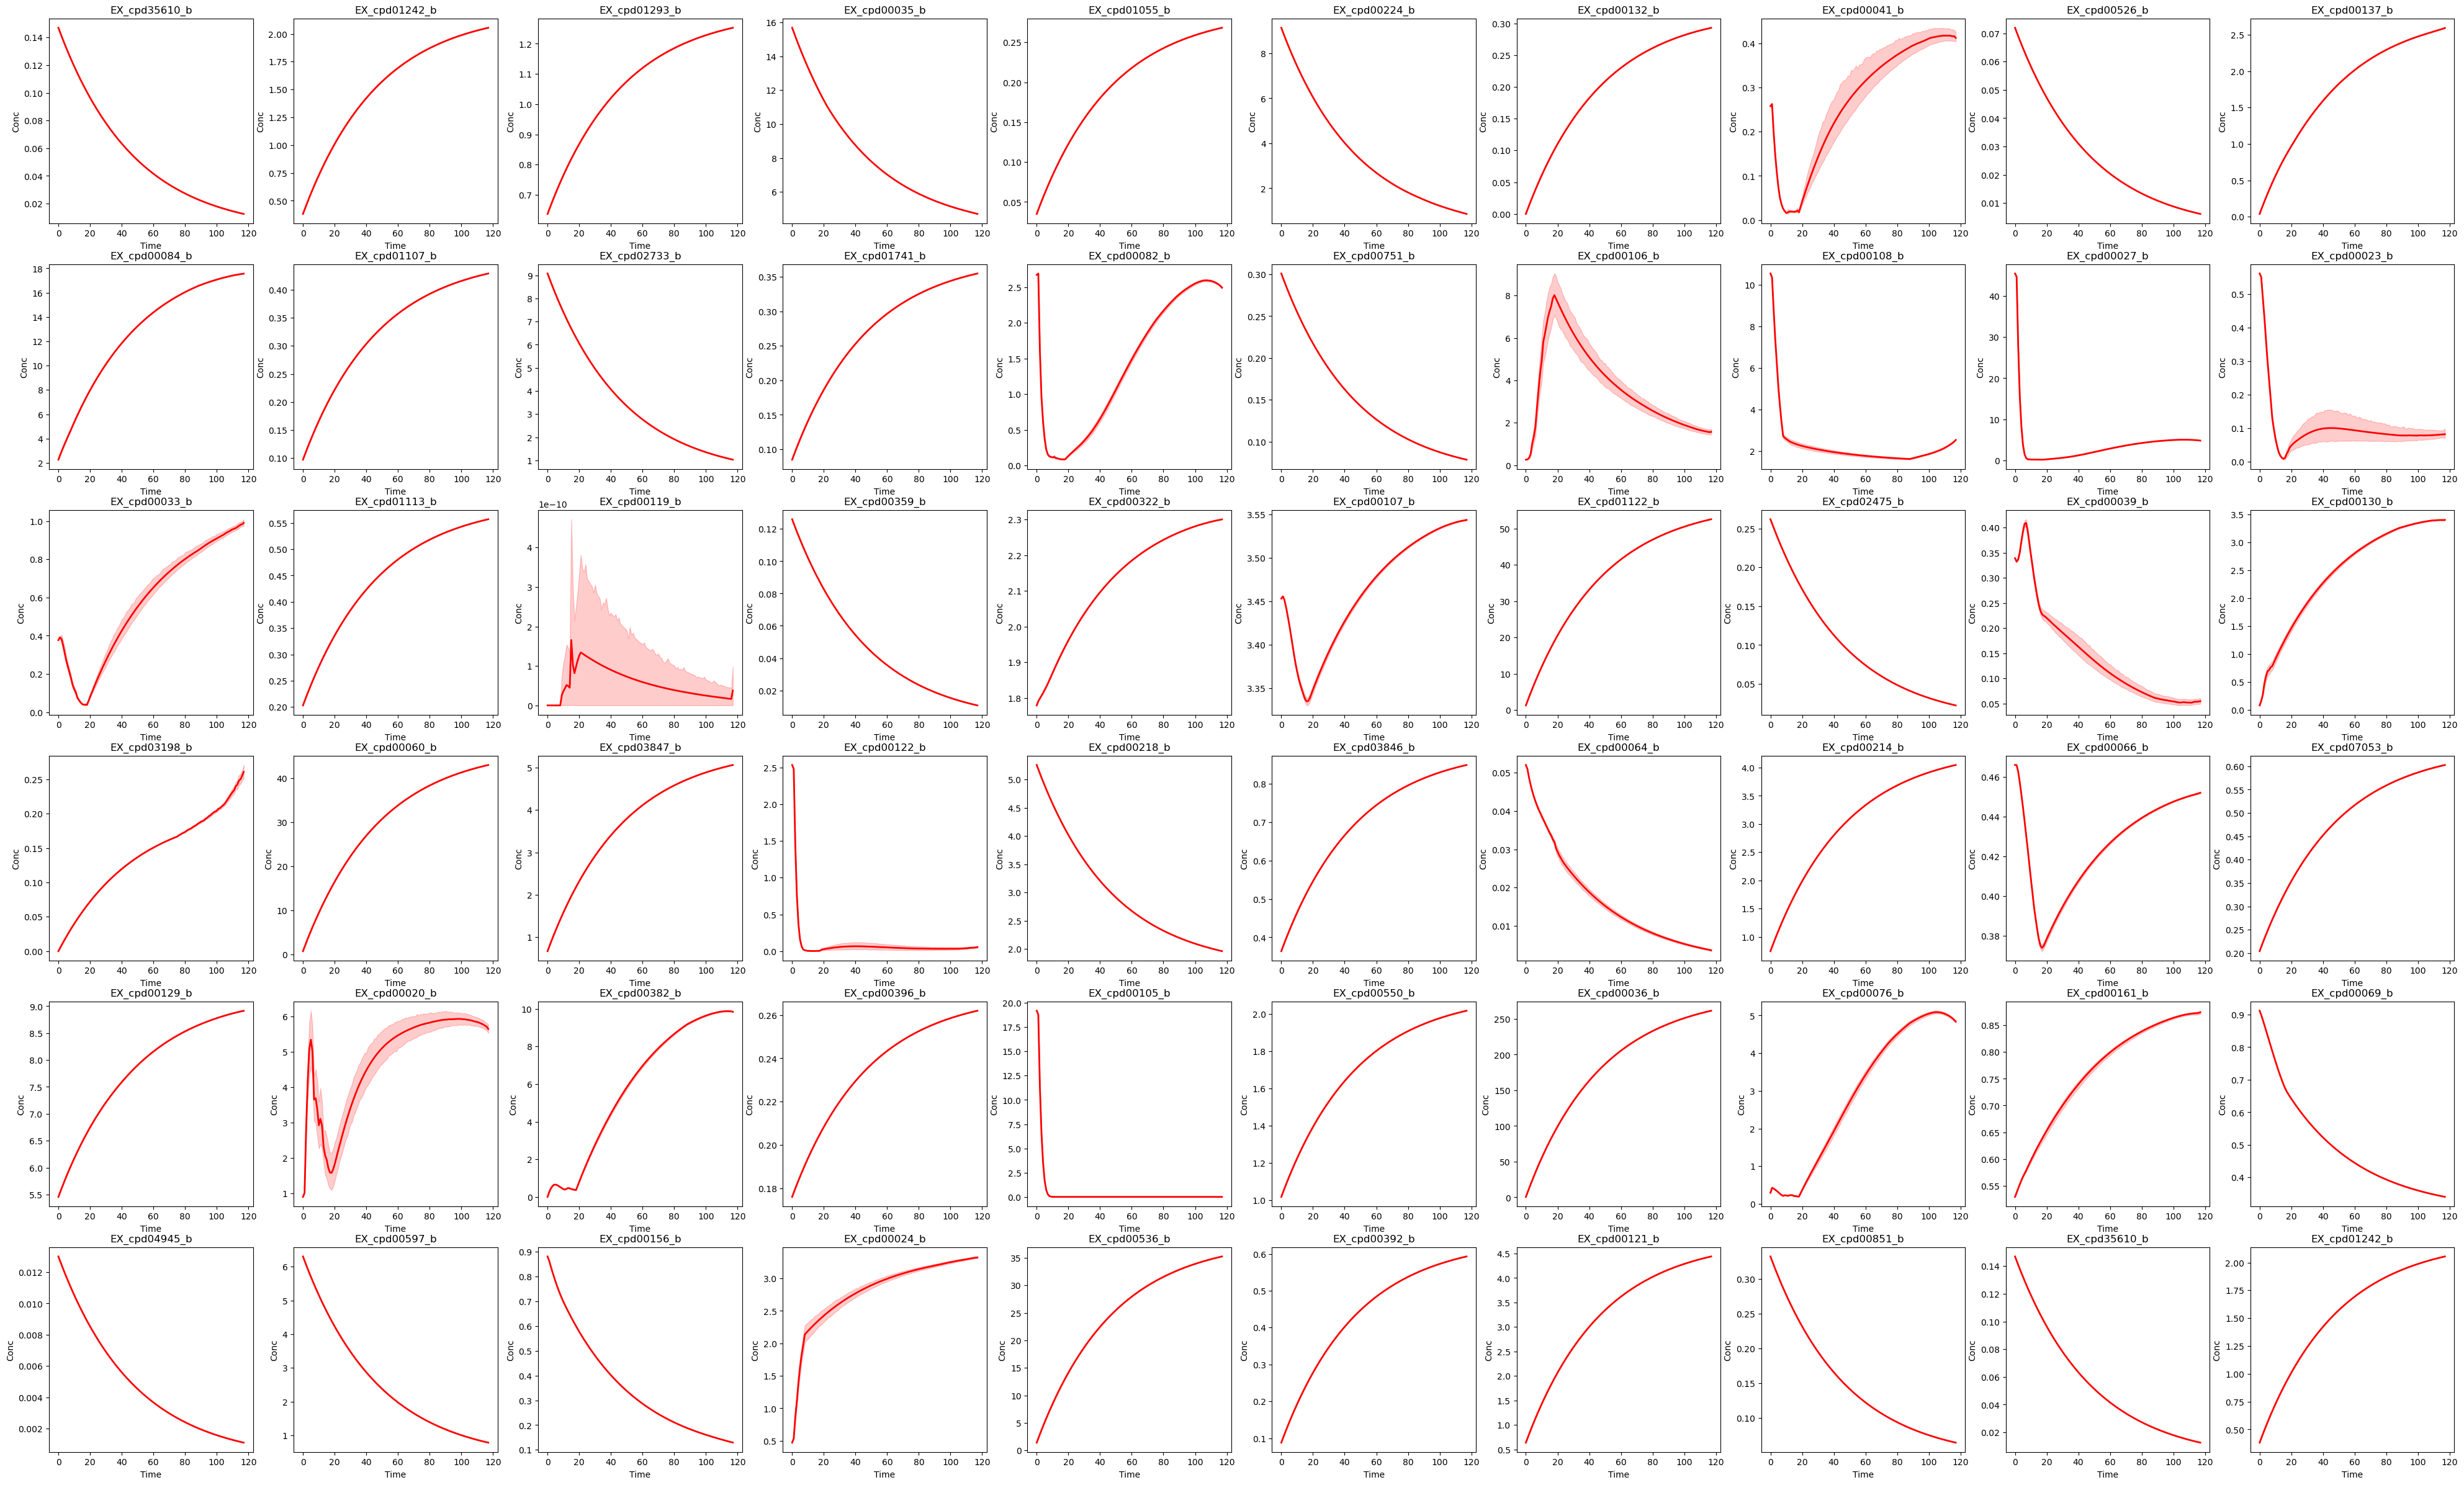

In [62]:
num_plots = 60
cols = 10  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i,met in enumerate(melted_df['reaction'].to_list()):
    temp_sim = melted_df[melted_df['reaction'] == met]
    #temp_exp = metabolomics_data_sub_1948.loc[met,:]
        # Scatter plot on the respective subplot
    sns.lineplot(ax=axes[i], data = temp_sim, x='time', y='fluxValue', color = 'red', lw = 2)
    #sns.lineplot(ax = axes[i], x = temp_sim.index.to_list(), y = list(savgol_filter(temp_sim.to_list(),300,3)), color = 'blue', lw = 2)
    #sns.scatterplot(ax=axes[i], x=temp_exp.index.to_list(), y=temp_exp.to_list())

    axes[i].set_title(f"{met}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Conc')
    #axes[i].set_yscale('log')
    #axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])